In [278]:
import os
from pathlib import Path

def encontrar_raiz_repo(marcador=".git"):
    caminho = Path.cwd()
    for pasta in [caminho, *caminho.parents]:
        if (pasta / marcador).exists():
            return pasta
    raise FileNotFoundError(f"Não achei {marcador} subindo a partir de {caminho}")

RAIZ = encontrar_raiz_repo()
print(RAIZ)

/usr/src/myapp


In [290]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

In [291]:
df_train = pd.read_csv(RAIZ / "data/processed/df_estruturada/df_train_com_clusters.csv", index_col=0)
df_valid = pd.read_csv(RAIZ / "data/processed/df_estruturada/df_valid.csv", index_col=0)
df_test = pd.read_csv(RAIZ / "data/processed/df_estruturada/df_test.csv", index_col=0)

metadata_cols = pd.read_csv(RAIZ / "data/processed/metadata_filtrada.csv")
metadata_cols = metadata_cols.set_index('sample')
metadata_alinhado = metadata_cols.loc[df_train.index]
top_especies = metadata_alinhado["Species"].value_counts().nlargest(10).index
especie_plot_completo = metadata_alinhado["Species"].where(
    metadata_alinhado["Species"].isin(top_especies), "Outras"
)

## K-NN

In [286]:
colunas_X = ['pct_genes_cromossomal_efflux', 'mdr_score_cromossomal',
       'mdr_score_plasmidial', 'pct_contigs_plasmidial', 'pct_plasmidial_amr',
       'pct_plasmidial_conjugacao_amr', 'n_proviruses_por_mb',
       'gc_diff_plasmid_cromossomo', 'virulence_score_cromossomal',
       'virulence_score_plasmidial', 'cat_plasmidial_beta-lactam']

In [284]:
df_train['agg_minmax'].value_counts()

3    1091
1    1064
0     942
4     807
2     697
5     325
Name: agg_minmax, dtype: int64

In [289]:
X_train = df_train[colunas_X].copy()
y_train = df_train["agg_minmax"]

In [292]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(df_test[colunas_X])

In [293]:
k = len(y_train.value_counts().values) 
knn_classifier = KNeighborsClassifier(n_neighbors=k)
knn_classifier.fit(X_train_scaled, y_train)

,n_neighbors,6
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [302]:
def treinamento_modelos_knn(target: str, df_teste: pd.DataFrame) -> tuple:
    # Divisão das variáveis dependente e independentes
    X = df_teste[colunas_X].copy()
    y = df_teste[target]

    # Divisão de teste e treino
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Padronização dos dados
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Determinação do modelo
    knn_classifier = KNeighborsClassifier(n_neighbors=6)
    knn_classifier.fit(X_train_scaled, y_train)

    # Determinação de predição
    y_pred = knn_classifier.predict(X_test_scaled)

    return y_test, y_pred, knn_classifier

In [304]:
y_test, y_pred, _knn_classifier = treinamento_modelos_knn(target='agg_minmax', df_teste=df_train)

In [305]:
def metricas(y_test: pd.Series | list, y_pred: np.ndarray, target: str) -> None:
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=y_test.value_counts().index,
    )
    disp.plot(cmap=plt.cm.Greens)
    plt.title(f"{target}'s cluster: Accuracy {accuracy:.2f}")
    plt.show()
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

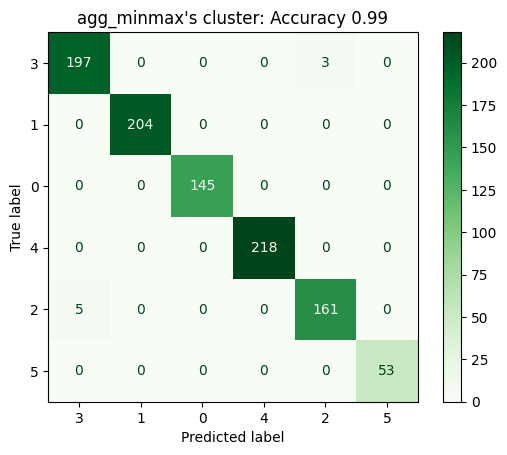


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       200
           1       1.00      1.00      1.00       204
           2       1.00      1.00      1.00       145
           3       1.00      1.00      1.00       218
           4       0.98      0.97      0.98       166
           5       1.00      1.00      1.00        53

    accuracy                           0.99       986
   macro avg       0.99      0.99      0.99       986
weighted avg       0.99      0.99      0.99       986



In [306]:
metricas(y_pred=y_pred, y_test=y_test, target='agg_minmax')

## Regressão Logistica

In [307]:
target = "agg_minmax"